# 1D Image Blurring and Restoration — Phase 2
## Computational Micro-Project

**Course:** 24BSE2113-D — Partial Differential Equations, Transforms and Optimization Techniques

**Topic:** Topic 2 — 1D Image Blurring and Restoration Using the Heat Equation

**Group Number:** 6

### Members
1. Dheekshan N Sreejith (27)
2. Abel Vincent (2)
3. Fiza Anish (28)
4. PR Amrutha (54)
5. Rihan S Muhammed (56)

**Course Coordinator:** Siju K S

## 1. Computational Approach

In Phase 1, the one-dimensional heat equation was solved analytically
for a scan line containing a sharp step-edge intensity profile.

The governing equation is

$$
\frac{\partial I(x,t)}{\partial t}
=
\alpha
\frac{\partial^2 I(x,t)}{\partial x^2},
\qquad 0<x<L,\quad t>0
$$

with the initial condition

$$
I(x,0)=
\begin{cases}
0, & 0\leq x<\frac{L}{2}\\
1, & \frac{L}{2}\leq x\leq L
\end{cases}
$$

and homogeneous Neumann boundary conditions

$$
\frac{\partial I(0,t)}{\partial x}=0,
\qquad
\frac{\partial I(L,t)}{\partial x}=0.
$$

The Fourier cosine-series solution obtained in Phase 1 is

$$
I(x,t)=
\frac{1}{2}
-
\sum_{n=1}^{\infty}
\frac{2}{n\pi}
\sin\left(\frac{n\pi}{2}\right)
\cos\left(\frac{n\pi x}{L}\right)
e^{-\alpha(n\pi/L)^2t}.
$$

In this notebook, the Fourier series is truncated to a finite number
of terms and implemented using NumPy. The intensity profile is
visualised at different times to observe the blurring process.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Physical parameters
L = 1.0
alpha = 0.01

# Fourier series truncation
N_terms = 300

# Time values for visualisation
t_values = [0.0, 0.1, 0.5]

print(f"L = {L}")
print(f"alpha = {alpha}")
print(f"N_terms = {N_terms}")
print(f"Visualising I(x,t) at t = {t_values}")

L = 1.0
alpha = 0.01
N_terms = 300
Visualising I(x,t) at t = [0.0, 0.1, 0.5]


## 2. Analytical (Fourier Series) Solution

For the Neumann boundary conditions, the solution is expressed as a
Fourier cosine series.

The Fourier coefficient is

$$
a_n=
-\frac{2}{n\pi}
\sin\left(\frac{n\pi}{2}\right).
$$

The following function evaluates the truncated Fourier series
numerically.

In [4]:
def a_n(n):
    """Fourier cosine coefficient for the step-edge initial condition."""
    return -(2.0 / (n * np.pi)) * np.sin(n * np.pi / 2)


def I_fourier(x, t, N=N_terms, L=L, alpha=alpha):
    """Evaluate the truncated Fourier cosine series solution I(x,t)."""

    x = np.atleast_1d(x).astype(float)

    n = np.arange(1, N + 1).reshape(-1, 1)

    coefficients = a_n(n)

    terms = (
        coefficients
        * np.cos(n * np.pi * x / L)
        * np.exp(-alpha * (n * np.pi / L)**2 * t)
    )

    return 0.5 + np.sum(terms, axis=0)

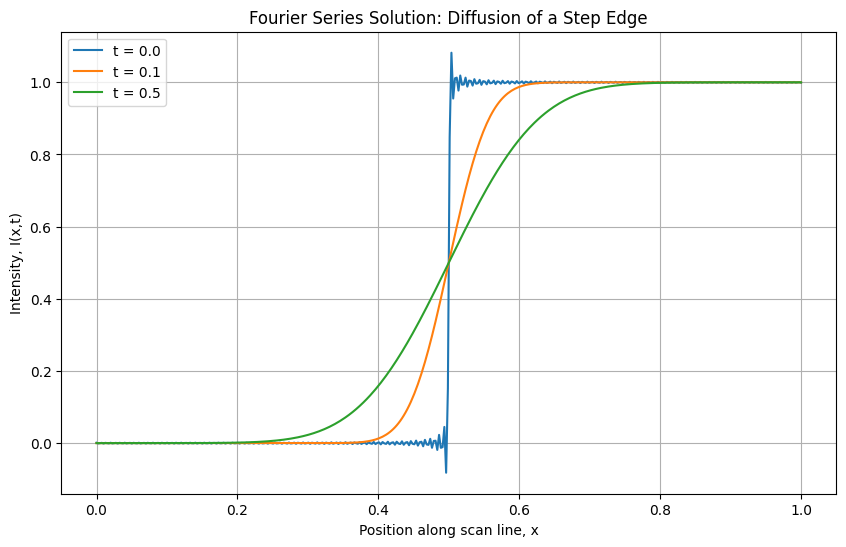

In [5]:
# Spatial grid
x_plot = np.linspace(0, L, 400)

plt.figure(figsize=(10, 6))

for t in t_values:
    plt.plot(
        x_plot,
        I_fourier(x_plot, t),
        label=f"t = {t}"
    )

plt.xlabel("Position along scan line, x")
plt.ylabel("Intensity, I(x,t)")
plt.title("Fourier Series Solution: Diffusion of a Step Edge")
plt.legend()
plt.grid(True)
plt.show()

### Observation

At $t=0$, the truncated Fourier series represents the initial sharp
step-edge profile. As time increases, the intensity transition around
$x=L/2$ becomes progressively smoother.

This shows the blurring effect produced by diffusion. The higher
spatial-frequency components decay faster because their decay rate is
proportional to $n^2$.

## 3. 3D Visualisation

The intensity $I(x,t)$ is evaluated over a range of positions and
times to visualise the complete space-time evolution of the
diffusing step edge.

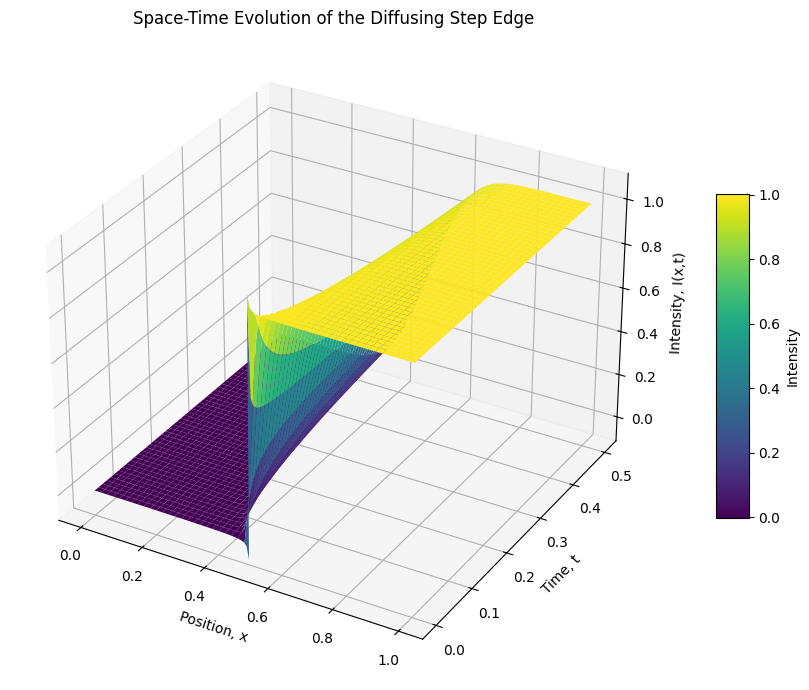

In [6]:
x_surface = np.linspace(0, L, 150)
t_surface = np.linspace(0, 0.5, 100)

X, T = np.meshgrid(x_surface, t_surface)

# Evaluate I(x,t) over the full grid
Z = np.array([
    I_fourier(x_surface, t)
    for t in t_surface
])

fig = plt.figure(figsize=(12, 7))

ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X, T, Z,
    cmap='viridis',
    edgecolor='none'
)

ax.set_xlabel("Position, x")
ax.set_ylabel("Time, t")
ax.set_zlabel("Intensity, I(x,t)")

ax.set_title("Space-Time Evolution of the Diffusing Step Edge")

fig.colorbar(
    surf,
    shrink=0.5,
    aspect=10,
    label="Intensity"
)

plt.tight_layout()
plt.show()

## 4. Physical Interpretation and Engineering Conclusions

- **Blurring as low-pass filtering:** The sharp edge gradually becomes
  smoother as time increases because the higher spatial-frequency
  components decay faster.

- **Effect of Neumann boundaries:** The zero-gradient boundary
  conditions represent the absence of intensity flow through the ends
  of the scan line.

- **Engineering relevance:** The computational results confirm the
  analytical solution obtained in Phase 1 and demonstrate how heat
  diffusion can be used to model image blurring.